In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


In [8]:
df=pd.read_csv('data/StudentsPerformance.csv')

In [9]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
X=df.drop(columns=['math score'],axis=1)

In [19]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [17]:
y=df['math score']

In [20]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [ ]:
## creating column transformer with 3 types of transformers
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor=ColumnTransformer(
    [
        ("oneHotEncoder",OneHotEncoder(),cat_features),
        ("StandardScaler",StandardScaler(),num_features),
    ]
) 


In [29]:
X=preprocessor.fit_transform(X)

In [32]:
X.shape

(1000, 19)

In [33]:
from sklearn.model_selection import train_test_split

In [ ]:
## splitting the dat as training and testing data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

### Evaluation function 

In [39]:
def evaluate_model(true,pred):
    mae=mean_absolute_error(true,pred)
    mse=mean_squared_error(true,pred)
    rmse=np.sqrt(mean_squared_error(true,pred))
    r2_square=r2_score(true,pred)
    return mae,rmse,r2_square

In [ ]:
models={
    'LinearRegression':LinearRegression(),
    'Lasso':Lasso(),
    'ridge':Ridge(),
    'K-Neighbors Regressor':KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest regressor':RandomForestRegressor(),
    'XGBRegressor':XGBRegressor(),
    'CatBoostRegressor':CatBoostRegressor(verbose=False),
    'AdaBoostRegressor':AdaBoostRegressor()
}
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    # predicting the output
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    # Evaluating the model
    model_train_mae,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])


    print("model performance for training set")
    print("- Root Mean squared Error :{:.4f}".format(model_train_rmse))
    print("-  Mean absolute Error:{:.4f}".format(model_train_mae))
    print("-r2 score {:.4f}".format(model_train_r2))

    print("-------------------------------------")
    print("model performance for test set")
    print("- Root Mean squared Error :{:.4f}".format(model_test_rmse))
    print("-  Mean absolute Error:{:.4f}".format(model_test_mae))
    print("-r2 score {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('===================================')
    print('\n')
        


LinearRegression
model performance for training set
- Root Mean squared Error :5.3402
-  Mean absolute Error:4.2723
-r2 score 0.8735
-------------------------------------
model performance for test set
- Root Mean squared Error :5.4214
-  Mean absolute Error:4.2253
-r2 score 0.8792


Lasso
model performance for training set
- Root Mean squared Error :6.5938
-  Mean absolute Error:5.2063
-r2 score 0.8071
-------------------------------------
model performance for test set
- Root Mean squared Error :6.5197
-  Mean absolute Error:5.1579
-r2 score 0.8253


ridge
model performance for training set
- Root Mean squared Error :5.3233
-  Mean absolute Error:4.2650
-r2 score 0.8743
-------------------------------------
model performance for test set
- Root Mean squared Error :5.3904
-  Mean absolute Error:4.2111
-r2 score 0.8806


K-Neighbors Regressor
model performance for training set
- Root Mean squared Error :5.7091
-  Mean absolute Error:4.5175
-r2 score 0.8554
-----------------------------

## Result

In [46]:
result=pd.DataFrame(list(zip(model_list,r2_list)),columns=['model name','r2_score']).sort_values(by=['r2_score'],ascending=False)

In [47]:
result

,model name,r2_score
2,ridge,0.880593
0,LinearRegression,0.879216
5,Random Forest regressor,0.853146
7,CatBoostRegressor,0.851632
8,AdaBoostRegressor,0.850012
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783497
4,Decision Tree,0.736458


In [ ]:
linear_model=LinearRegression()
lin_model=linear_model.set_partial_fit_request(X_train, y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)
print("Accuracy of the model is :",score)


Accuracy of the model is : 0.8792164757750934


### plotting test and predicted data

Text(0, 0.5, 'predicted')

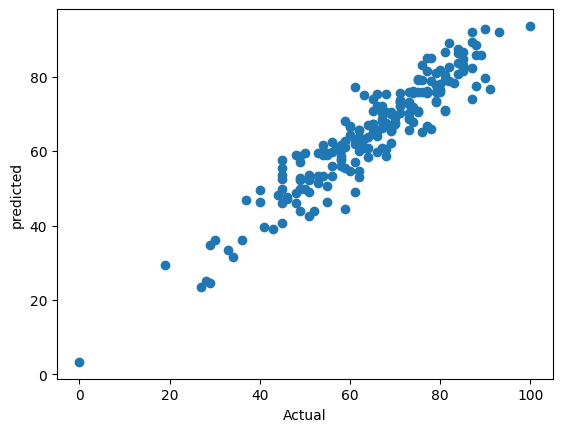

In [54]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("predicted")

<Axes: xlabel='math score'>

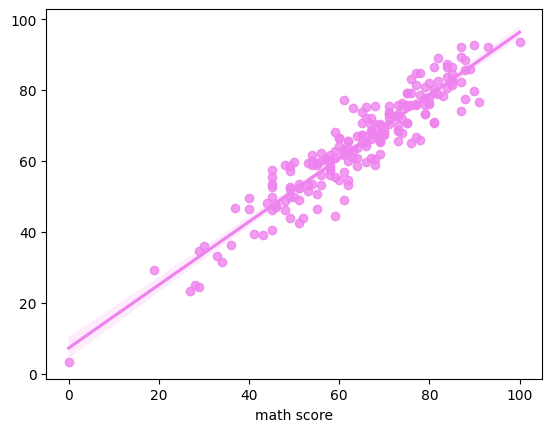

In [59]:
sns.regplot(data=df,x=y_test,y=y_pred,color='violet')